# W06 · Multi-Agent RL — Two-Rover Cooperative Patrol

Hongyu LIU · InGen Dynamics — ML & NN Analyst Intern, July 2026

**Platform:** Aido Rover (two-rover coverage patrol) · Origami / PIC 2.0 (CRL-MRS)
**Protocol:** 5 train seeds (0–4) × 10 fixed evaluation world seeds · γ = 0.99 per option decision · **Deployment gate:** ≤100 ms per decision, now with two policy forward passes

Two rovers patrol the same map. The cooperative problem is coverage: keep every main-route edge
recently visited without both rovers sweeping the same stretch. Independent learners are trained under
two reward schemes so that the credit-assignment difficulty is measured rather than asserted.

## 1. What the World Core Provides, and What It Does Not

The Week-2 world-core design specified the mechanism for this week: two `RoverWorld` instances on a
shared map, each passed as the other's `dynamic_obstacles` so they see each other. The hook exists in
the frozen core — the extra circles are merged into the LiDAR ray-cast, which also drives the
GPS-multipath term — and it is used here unchanged. It is necessary but not sufficient, for three
reasons that shaped the wrapper.

**Perception without consequence.** `halted` is set solely by the blockage table, so two rovers pass
through each other with no effect on motion. A collision cost therefore has to be a wrapper-level
reward term; adding it to the core would break the Week-5 offline↔online replay gate.

**Local signal, global problem.** LiDAR reaches 200 m and the main loop is 960 m, so mutual visibility
resolves the partner only when the two are already close — exactly when coordination has already
failed. Splitting a patrol loop into sectors needs the partner's position across the whole loop, so
the observation carries an explicit partner block (`route_progress`, SoC, and a signed loop gap) in
addition to the LiDAR channel that carries the local signal.

**No coverage state.** `RoverWorld` tracks one rover's pose and battery and nothing about which edges
have been visited when, so the shared objective lives entirely in the wrapper.

Decisions are taken at node level, matching the hierarchical environment: coordination here is a
routing and sector-splitting problem, and running it at 10 Hz would multiply training cost without
adding coordination content. The 10 Hz mutual `dynamic_obstacles` exchange still happens inside option
execution, so the Week-2 design decision is realised rather than discarded.

In [1]:
import json, sys, warnings
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')
torch.set_num_threads(1)

from shared_modules.rl_eval import ART_DIR, EVAL_WORLD_SEEDS, W5_EVAL_SEEDS, N_TRAIN_SEEDS, \
    W6_TIMESTEPS, GAMMA, verify_w5_reference_gate, paired_test

SEED = 42
BLUE, ORANGE, GREEN, RED, GREY = '#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8C8C8C'
IMG_DIR = Path('../reports/image/W06_MultiAgent_RL'); IMG_DIR.mkdir(parents=True, exist_ok=True)


def save(fig, name):
    fig.savefig(IMG_DIR / name, bbox_inches='tight', dpi=130)


from rl.rover_multiagent_env import RoverMultiAgentEnv, OPTION_NAMES, AGENTS, ROVER_RADIUS

print('agents  ', AGENTS)
print('options ', OPTION_NAMES)
print('rover LiDAR radius presented to the partner:', ROVER_RADIUS, 'm')

agents   ['rover_0', 'rover_1']
options  {0: 'patrol-edge', 1: 'reroute-branch', 2: 'slow-traverse', 3: 'dock'}
rover LiDAR radius presented to the partner: 0.6 m


## 2. Environment API Check

PettingZoo's `parallel_api_test` is run first, on the same principle as the Week-5 `check_env` gate:
no training result is worth reading until the environment is known to satisfy the API contract.

In [2]:
from pettingzoo.test import parallel_api_test
env = RoverMultiAgentEnv(reward_mode='shared', max_env_steps=2400)
parallel_api_test(env, num_cycles=8)
env.close()
print('parallel_api_test passed')

Passed Parallel API test
parallel_api_test passed


## 3. Does the Mutual-Visibility Mechanism Actually Fire?

The claim that the two rovers see each other should be measured, not assumed. The same episode is run
twice — once with each rover injected into the other's `dynamic_obstacles`, once with the injection
disabled — and the LiDAR channel is compared. Any difference is attributable to the partner, because
the world seeds, map and action sequences are identical.

,separation,steps,p_detect_geometric,geo_off,geo_on,lidar_on,mean_drop
0,0-2 m,40,0.650,23.1,8.5,13.5,14.6
1,2-5 m,64,1.000,23.1,2.8,12.1,20.3
2,5-10 m,100,1.000,23.1,6.8,18.4,16.3
3,10-15 m,100,1.000,23.1,11.8,13.6,11.3
4,15-20 m,119,1.000,23.1,16.8,23.0,6.2
5,20-25 m,101,0.653,23.1,21.7,23.4,1.4
6,25-30 m,100,0.000,23.1,23.1,24.9,0.0
7,30-inf m,2376,0.000,22.3,22.3,25.5,0.0


geometric return with no partner : {'mean': 22.5, 'median': 23.1, 'max': 23.1}
measured LiDAR with no partner   : {'mean': 26.0, 'median': 23.1, 'max': 200.0}


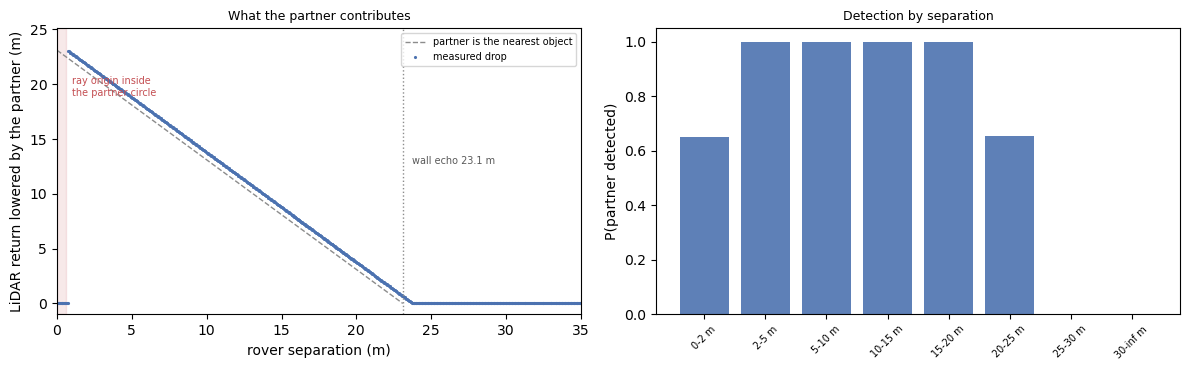

beyond 30 m the partner changes the return on 0 of 2376 steps


In [3]:
from rl.rover_multiagent_env import mutual_visibility_probe, ROVER_RADIUS
probe = mutual_visibility_probe(world_seed=0, n_steps=3000)
display(pd.DataFrame(probe['summary']))
print('geometric return with no partner :', probe['no_partner_geometric'])
print('measured LiDAR with no partner   :', probe['no_partner_measured'])

sep = probe['separation']
drop = probe['geo_off'] - probe['geo_on']          # what the partner alone contributes
wall = probe['no_partner_geometric']['median']

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
# The x axis is Euclidean separation, which is not monotone in time: the route is a boustrophedon,
# so the leader rounding a node closes the straight-line gap while both rovers keep driving.
# Plotting the raw return against it therefore traces the follower's own wall geometry as well.
# The partner-attributable drop is zero wherever the partner is invisible, so it isolates the signal.
axes[0].axvspan(0, ROVER_RADIUS, color=RED, alpha=0.12)
axes[0].text(ROVER_RADIUS + 0.4, wall * 0.82, 'ray origin inside\nthe partner circle',
             fontsize=7, color=RED)
axes[0].plot([0, wall], [wall, 0], ls='--', lw=1, color=GREY,
             label='partner is the nearest object')
axes[0].plot(sep, drop, '.', ms=2.5, color=BLUE, label='measured drop')
axes[0].axvline(wall, ls=':', lw=1, color=GREY)
axes[0].text(wall + 0.6, wall * 0.55, f'wall echo {wall:.1f} m', fontsize=7, color='0.35')
axes[0].set_xlim(0, 35); axes[0].set_ylim(-1, wall + 2)
axes[0].set_xlabel('rover separation (m)')
axes[0].set_ylabel('LiDAR return lowered by the partner (m)')
axes[0].set_title('What the partner contributes', fontsize=9)
axes[0].legend(fontsize=7)

s = pd.DataFrame(probe['summary'])
axes[1].bar(range(len(s)), s['p_detect_geometric'], color=BLUE, alpha=0.9)
axes[1].set_xticks(range(len(s))); axes[1].set_xticklabels(s['separation'], rotation=45, fontsize=7)
axes[1].set_ylabel('P(partner detected)'); axes[1].set_title('Detection by separation', fontsize=9)
plt.tight_layout(); save(fig, 'mutual_visibility.png'); plt.show()

far = sep > 30
print(f'beyond 30 m the partner changes the return on {int((drop[far] > 0.5).sum())} of {int(far.sum())} steps')

The measurement records the *following* rover's channel. `cast_min` sweeps a forward 120° fan, so the
exchange is not symmetric — a rover behind its partner sees it, a rover ahead sees nothing, and
recording the leader's channel returns a detection rate of zero at every separation. The separation is
swept deliberately: both rovers start at the same node with one at cruise and one at half speed. Left
to themselves on a shared world seed the two RNG streams stay in lockstep and the rovers remain exactly
superimposed, sampling no range at all.

## 4. Reward Schemes and the Credit-Assignment Problem

Both schemes share the same team quantity: the sum of the two per-agent Week-5 rewards, plus a bonus
for each freshly traversed edge whose staleness exceeded the threshold, minus a penalty for covering an
edge the partner covered recently, minus a per-step proximity cost.

- **`shared`** gives both agents that team reward. An agent cannot tell which part of it caused, so a
  rover that does nothing useful still collects the partner's contribution — the standard
  credit-assignment failure mode, and the one CRL-MRS has to solve.
- **`difference`** gives each agent the team reward minus the team reward that would have accrued
  without that agent's traversals and position — a counterfactual baseline. The comparison between the
  two is what makes the difficulty measurable instead of anecdotal.

In [4]:
DISPLAY_MARL = [
    ('marl_shared', 'independent PPO, shared team reward'),
    ('marl_difference', 'independent PPO, difference reward'),
]


def load_marl_evals(n_seeds=5):
    """Per-reward-mode multi-agent results, aggregated across train seeds."""
    out = {}
    for tag, _ in DISPLAY_MARL:
        ds = [json.loads((ART_DIR / f'{tag}_s{s}_meta.json').read_text())
              for s in range(n_seeds) if (ART_DIR / f'{tag}_s{s}_meta.json').exists()]
        if not ds:
            continue
        ev = [d['eval'] for d in ds]
        keys = [k for k in ev[0] if isinstance(ev[0][k], (int, float))]
        out[tag] = dict(tag=tag, n_train_seeds=len(ds),
                        **{k: float(np.mean([e[k] for e in ev])) for k in keys})
    return out


def marl_table(me):
    rows = []
    for tag, label in DISPLAY_MARL:
        d = me.get(tag)
        if d is None:
            continue
        r = {'reward scheme': label, 'n seeds': d['n_train_seeds']}
        r.update({k.replace('_', ' '): round(v, 3) for k, v in d.items()
                  if k not in ('tag', 'n_train_seeds')})
        rows.append(r)
    return pd.DataFrame(rows)


me = load_marl_evals()
marl_table(me).T

,0,1
reward scheme,"independent PPO, shared team reward","independent PPO, difference reward"
n seeds,5,5
latency ms,0.189,0.192
team return mean,3819.087,3839.908
team return std,1033.735,1061.863
coverage frac mean,0.735,0.733
coverage frac std,0.062,0.066
redundant edges mean,1.3,1.18
proximity steps mean,6.44,6.44
decisions mean,8.78,8.54


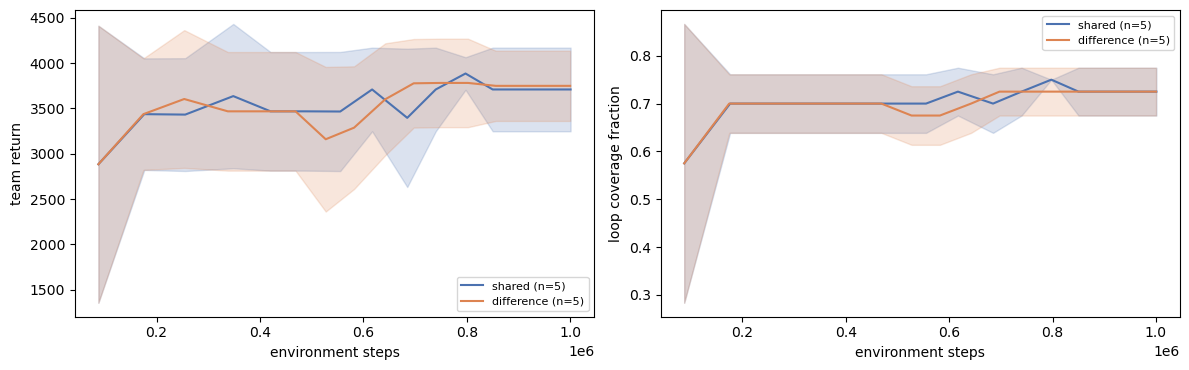

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for mode, c in [('shared', BLUE), ('difference', ORANGE)]:
    curves = []
    for s in range(5):
        p = ART_DIR / f'marl_{mode}_s{s}_meta.json'
        if not p.exists(): continue
        cur = json.loads(p.read_text())['curve']
        curves.append((cur['env_steps'], cur['team_return'], cur['coverage_frac']))
    if not curves: continue
    k = min(len(x[0]) for x in curves)
    x = np.array(curves[0][0][:k])
    for j, ax in enumerate(axes):
        y = np.array([c[j + 1][:k] for c in curves])
        ax.plot(x, y.mean(0), color=c, label=f'{mode} (n={len(curves)})')
        ax.fill_between(x, y.mean(0) - y.std(0), y.mean(0) + y.std(0), alpha=0.2, color=c)
axes[0].set_ylabel('team return'); axes[1].set_ylabel('loop coverage fraction')
for ax in axes:
    ax.set_xlabel('environment steps'); ax.legend(fontsize=8)
plt.tight_layout(); save(fig, 'marl_curves.png'); plt.show()

## 5. Deployment Latency with Two Policies

A two-rover step runs two policy forward passes. The single-agent conclusion — a small MLP is three
orders of magnitude inside the gate — does not automatically transfer, so the two-policy path is
measured directly rather than inferred.

In [6]:
import timeit
from rl.harness.train import load_agents
ag = load_agents('marl_difference', 0)
obs = {a: np.zeros(ag[a].obs_dim, dtype=np.float32) for a in AGENTS}
one = timeit.timeit(lambda: ag[AGENTS[0]].act(obs[AGENTS[0]], deterministic=True), number=2000) / 2000
both = timeit.timeit(lambda: {a: ag[a].act(obs[a], deterministic=True) for a in AGENTS},
                     number=2000) / 2000
lat = pd.DataFrame([{'path': 'single rover policy', 'latency (ms)': 1000 * one},
                    {'path': 'two rovers, one decision step', 'latency (ms)': 1000 * both}])
lat['verdict (100 ms gate)'] = np.where(lat['latency (ms)'] < 100, 'PASS', 'FAIL')
lat.round(4)

,path,latency (ms),verdict (100 ms gate)
0,single rover policy,0.0939,PASS
1,"two rovers, one decision step",0.1897,PASS
